In [ ]:
import numpy as np

In [ ]:
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt


In [ ]:
from numpy.linalg import eig
np.random.seed(1)
x1 = np.random.normal(loc=50, scale=3, size=50)
x2 = 0.5 * x1 + np.random.normal(loc=0, scale=np.sqrt(3), size=50)
dataset = pd.DataFrame({"x1": x1, "x2": x2})
print(dataset.head())
plt.figure()

          x1         x2
0  54.873036  27.956428
1  48.164731  23.472251
2  48.415485  22.228843
3  46.781094  22.785468
4  52.596223  25.936296


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

      mu_x1     mu_x2
0  4.949581  2.740642
1 -1.758725 -1.743535
2 -1.507971 -2.986943
3 -3.142361 -2.430318
4  2.672767  0.720510


Text(0.5, 0, 'mu_x1')

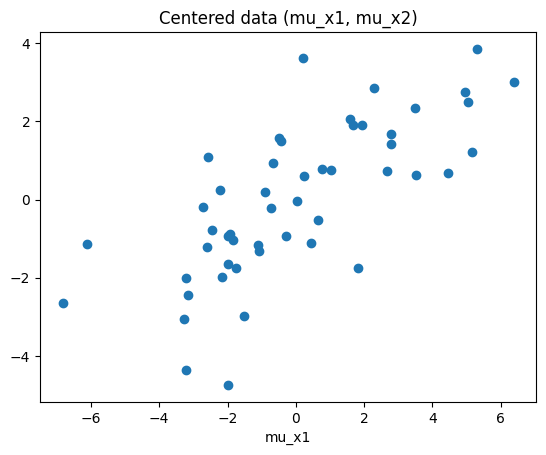

In [ ]:
dataset_centered = dataset.copy()
dataset_centered["mu_x1"] = dataset["x1"] - dataset["x1"].mean()
dataset_centered["mu_x2"] = dataset["x2"] - dataset["x2"].mean()
print(dataset_centered[["mu_x1", "mu_x2"]].head())
plt.figure()
plt.scatter(dataset_centered["mu_x1"], dataset_centered["mu_x2"])
plt.title("Centered data (mu_x1, mu_x2)")
plt.xlabel("mu_x1")

Covariance matrix:
 [[8.63360245 4.22609685]
 [4.22609685 3.94139228]]

Eigenvalues:
 [11.12114026  1.45385447]

Eigenvectors (columns are eigenvectors):
 [[ 0.86179173 -0.50726228]
 [ 0.50726228  0.86179173]]

PC1 eigenvector: [0.86179173 0.50726228]
PC2 eigenvector: [-0.50726228  0.86179173]

PC1 slope: 0.588613536483608
PC2 slope: -1.6989075820002797


Text(0.5, 0, 'mu_x1')

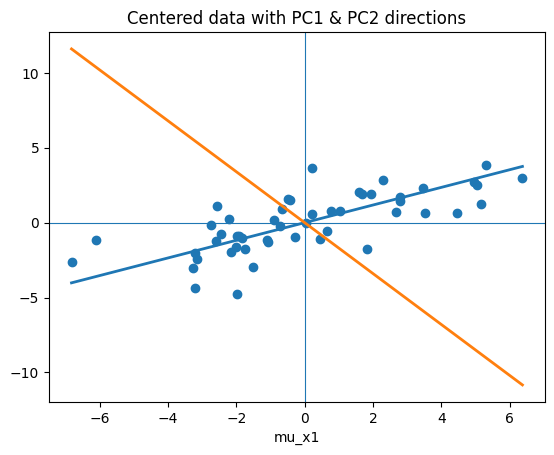

In [ ]:
# Selection of centered variables as matrix
X = dataset_centered[["mu_x1", "mu_x2"]].values # shape (n, 2)
# Covariance matrix (same formula as lab: (X^T X)/(n-1))
n = X.shape[0]
cov_mat = (X.T @ X) / (n - 1)
print("Covariance matrix:\n", cov_mat)
# Eigen decomposition
e_values, e_vectors = eig(cov_mat)
print("\nEigenvalues:\n", e_values)
print("\nEigenvectors (columns are eigenvectors):\n", e_vectors)
# Sort eigenvalues/eigenvectors descending by eigenvalue
idx = np.argsort(e_values)[::-1]
e_values = e_values[idx]
e_vectors = e_vectors[:, idx]
pc1 = e_vectors[:, 0]
pc2 = e_vectors[:, 1]
print("\nPC1 eigenvector:", pc1)
print("PC2 eigenvector:", pc2)
# Slopes for lines in 2D plot (y/x)
pc1_slope = pc1[1] / pc1[0]
pc2_slope = pc2[1] / pc2[0]
print("\nPC1 slope:", pc1_slope)
print("PC2 slope:", pc2_slope)
#Plot centered data with principal components directions
plt.figure()
plt.scatter(X[:, 0], X[:, 1], label="Centered points")
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
# Draw PC lines through origin
xline = np.linspace(X[:, 0].min(), X[:, 0].max(), 200)
plt.plot(xline, pc1_slope * xline, label="PC1", linewidth=2)
plt.plot(xline, pc2_slope * xline, label="PC2", linewidth=2)
plt.title("Centered data with PC1 & PC2 directions")
plt.xlabel("mu_x1")


In [ ]:
 #In PCA, eigenvalues of covariance matrix
#correspond to variance along PCs
variance = e_values
variance_ratio = variance / variance.sum()
variance_df = pd.DataFrame({
"PC": ["PC1", "PC2"],
"Variance": variance,
"Variance_Ratio": variance_ratio,
"Percent": variance_ratio * 100
})

Rotated data (first 5 rows):
 [[ 5.65573215 -0.1488726 ]
 [-2.400084   -0.61042947]
 [-2.81472024 -1.80918619]
 [-3.94086972 -0.50042674]
 [ 2.66885647 -0.73486443]]


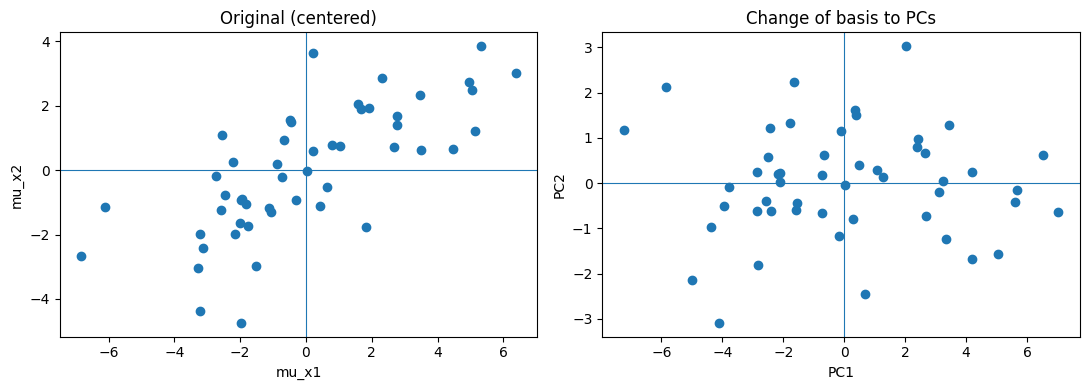

In [ ]:
# Rotated / transformed coordinates in PC space
X_rot = X @ e_vectors # (n,2) in PC basis
print("Rotated data (first 5 rows):\n", X_rot[:5])
# Plot original centered vs rotated (PC space)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(X[:, 0], X[:, 1])
ax[0].axhline(0, linewidth=0.8)
ax[0].axvline(0, linewidth=0.8)
ax[0].set_title("Original (centered)")
ax[0].set_xlabel("mu_x1")
ax[0].set_ylabel("mu_x2")
ax[1].scatter(X_rot[:, 0], X_rot[:, 1])
ax[1].axhline(0, linewidth=0.8)
ax[1].axvline(0, linewidth=0.8)
ax[1].set_title("Change of basis to PCs")
ax[1].set_xlabel("PC1")
ax[1].set_ylabel("PC2")
plt.tight_layout()
plt.show()

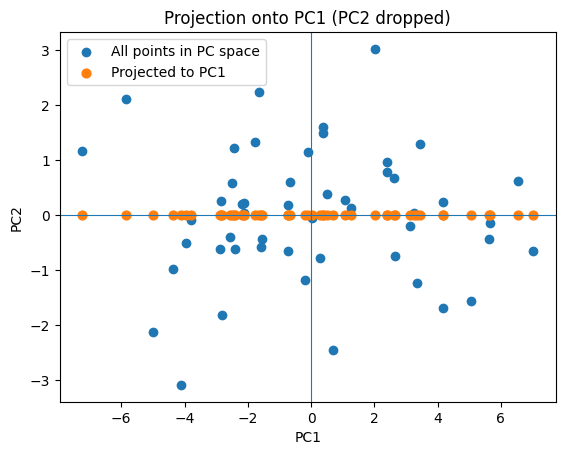

In [ ]:
X_pc1_only = np.column_stack([X_rot[:, 0], np.zeros(n)])
plt.figure()
plt.scatter(X_rot[:, 0], X_rot[:, 1], label="All points in PC space")
plt.scatter(X_pc1_only[:, 0], X_pc1_only[:, 1], label="Projected to PC1", s=40)
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.title("Projection onto PC1 (PC2 dropped)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

In [ ]:
pca_model = PCA(n_components=2)
pca_model.fit(dataset[["x1", "x2"]]) # PCA will center by default

NameError: name 'PCA' is not defined

In [ ]:
# ---- Try to load mtcars (R dataset) in Python ----
try:
  import statsmodels.api as sm
  mtcars = sm.datasets.get_rdataset("mtcars").data
  print("Loaded mtcars shape:", mtcars.shape)
except Exception as e:
  print("Could not load mtcars automatically.")
  print("Reason:", e)
  print("\nFallback: using seaborn 'mpg' dataset instead.")
  mtcars = sns.load_dataset("mpg").dropna()
  print("Loaded mpg shape:", mtcars.shape)
print(mtcars.head())
print(mtcars.info())

Loaded mtcars shape: (32, 11)
                    mpg  cyl   disp   hp  drat     wt   qsec  vs  am  gear  \
rownames                                                                     
Mazda RX4          21.0    6  160.0  110  3.90  2.620  16.46   0   1     4   
Mazda RX4 Wag      21.0    6  160.0  110  3.90  2.875  17.02   0   1     4   
Datsun 710         22.8    4  108.0   93  3.85  2.320  18.61   1   1     4   
Hornet 4 Drive     21.4    6  258.0  110  3.08  3.215  19.44   1   0     3   
Hornet Sportabout  18.7    8  360.0  175  3.15  3.440  17.02   0   0     3   

                   carb  
rownames                 
Mazda RX4             4  
Mazda RX4 Wag         4  
Datsun 710            1  
Hornet 4 Drive        1  
Hornet Sportabout     2  
<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, Mazda RX4 to Volvo 142E
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mpg     32 non-null     float64
 1   cyl     32 

Explained variance ratio (first 10 PCs):
[0.60076366 0.24095163 0.05701793 0.02450886 0.02031374 0.01923601
 0.01229654 0.01117286 0.00700424 0.00473049]

Cumulative variance (first 10 PCs):
[0.60076366 0.84171529 0.89873322 0.92324208 0.94355581 0.96279183
 0.97508837 0.98626123 0.99326547 0.99799596]


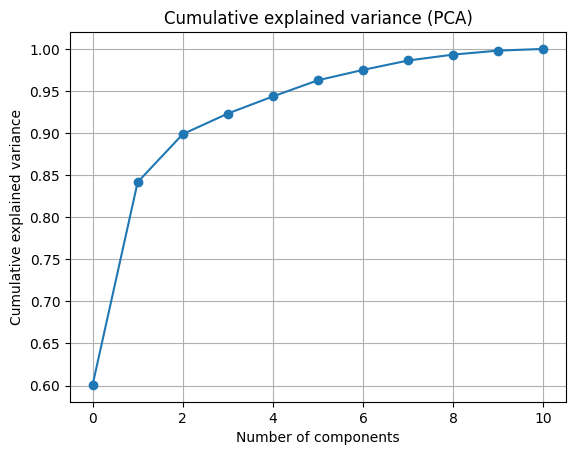

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# Keep only numeric columns
X_real = mtcars.select_dtypes(include=[np.number]).copy()
# Standardize before PCA (important when features have
#different scales)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_real)
pca_real = PCA()
X_pca = pca_real.fit_transform(X_scaled)
print("Explained variance ratio (first 10 PCs):")
print(pca_real.explained_variance_ratio_[:10])
print("\nCumulative variance (first 10 PCs):")
print(np.cumsum(pca_real.explained_variance_ratio_[:10]))
plt.figure()
plt.plot(np.cumsum(pca_real.explained_variance_ratio_),
marker="o")
plt.title("Cumulative explained variance (PCA)")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.grid(True)
plt.show()

In [ ]:
A = np.array([
[ 4, -5, -1],
[ 7, -2, 3],
[-1, 4, -3],
[ 8, 2, 6]
], dtype=float)
print("A:\n", A)
U, s, Vt = np.linalg.svd(A, full_matrices=False)
print("\nU:\n", U)
print("\nSingular values:\n", s)
print("\nVt:\n", Vt)
# Build Sigma
Sigma = np.diag(s)
# Reconstruct A
A_recon = U @ Sigma @ Vt
print("\nReconstructed A:\n", A_recon)
print("\nReconstruction error (Frobenius norm):",
np.linalg.norm(A - A_recon))

A:
 [[ 4. -5. -1.]
 [ 7. -2.  3.]
 [-1.  4. -3.]
 [ 8.  2.  6.]]

U:
 [[-0.28165688 -0.73038485  0.42412326]
 [-0.59125368 -0.14630169  0.18371213]
 [ 0.22478227  0.40407167  0.88586638]
 [-0.72149942  0.53090476 -0.04012567]]

Singular values:
 [13.16120996  6.99989184  3.43279282]

Vt:
 [[-0.85571015  0.15552689 -0.49352966]
 [-0.01464091  0.94610374  0.32353262]
 [ 0.51724828  0.28407587 -0.80731352]]

Reconstructed A:
 [[ 4. -5. -1.]
 [ 7. -2.  3.]
 [-1.  4. -3.]
 [ 8.  2.  6.]]

Reconstruction error (Frobenius norm): 4.39625888431457e-15


In [ ]:
ATA = A.T @ A
evals_ATA, evecs_ATA =np.linalg.eig(ATA)
# Sort descending
idx = np.argsort(evals_ATA)[::-1]
evals_ATA = evals_ATA[idx]
V = evecs_ATA[:, idx]
print("A^T A:\n", ATA)
print("\nEigenvalues of A^T A:\n",
evals_ATA)
print("\nV (from eigenvectors of A^TA):\n", V)

A^T A:
 [[130. -22.  68.]
 [-22.  49.  -1.]
 [ 68.  -1.  55.]]

Eigenvalues of A^T A:
 [173.21744764  48.99848579  11.78406658]

V (from eigenvectors of A^TA):
 [[ 0.85571015 -0.01464091 -0.51724828]
 [-0.15552689  0.94610374 -0.28407587]
 [ 0.49352966  0.32353262  0.80731352]]


In [ ]:
sing_vals= np.sqrt(np.maximum(evals_ATA,
0))
print("\nSingular values from eig(A^T A):\n", sing_vals)


Singular values from eig(A^T A):
 [13.16120996  6.99989184  3.43279282]


In [ ]:
AAT = A @ A.T
evals_AAT, evecs_AAT = np.linalg.eig(AAT)
idx2 = np.argsort(evals_AAT)[::-1]
evals_AAT = evals_AAT[idx2]
U_from_AAT = evecs_AAT[:, idx2]
print("\nA A^T:\n", AAT)
print("\nU (from eigenvectors of A A^T):\n",
U_from_AAT)
# NOTE: Eigenvector signs can flip (+/-) and
#still be correct.


A A^T:
 [[ 42.  35. -21.  16.]
 [ 35.  62. -24.  70.]
 [-21. -24.  26. -18.]
 [ 16.  70. -18. 104.]]

U (from eigenvectors of A A^T):
 [[ 0.28165688  0.73038485 -0.42412326  0.45533156]
 [ 0.59125368  0.14630169 -0.18371213 -0.77153403]
 [-0.22478227 -0.40407167 -0.88586638 -0.0379443 ]
 [ 0.72149942 -0.53090476  0.04012567  0.44268346]]


In [ ]:
mtcars = pd.read_csv("mtcars.csv")

# Keep numeric columns only
X = mtcars.select_dtypes(include=[np.number])

# Standardize (CRUCIAL for PCA/SVD comparison)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print("PCA explained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nPCA singular values:")
print(pca.singular_values_)


PCA explained variance ratio:
[0.60076366 0.24095163 0.05701793 0.02450886 0.02031374 0.01923601
 0.01229654 0.01117286 0.00700424 0.00473049 0.00200404]

PCA singular values:
[14.54196713  9.20950447  4.47999025  2.93719559  2.67402979  2.6021291
  2.08047677  1.9831404   1.57018883  1.29040075  0.83989344]


In [ ]:
U, s, Vt = np.linalg.svd(X_scaled, full_matrices=False)

print("Singular values from SVD:")
print(s)


Singular values from SVD:
[14.54196713  9.20950447  4.47999025  2.93719559  2.67402979  2.6021291
  2.08047677  1.9831404   1.57018883  1.29040075  0.83989344]


In [ ]:
var_svd = (s**2) / np.sum(s**2)

print("\nExplained variance ratio from SVD:")
print(var_svd)



Explained variance ratio from SVD:
[0.60076366 0.24095163 0.05701793 0.02450886 0.02031374 0.01923601
 0.01229654 0.01117286 0.00700424 0.00473049 0.00200404]


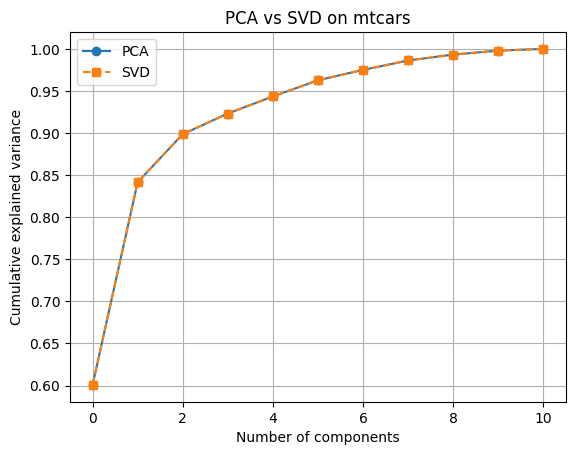

In [ ]:
plt.figure()
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o", label="PCA")
plt.plot(np.cumsum(var_svd), marker="s", linestyle="--", label="SVD")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA vs SVD on mtcars")
plt.legend()
plt.grid(True)
plt.show()
